# **Unsupervised Learning: Dimensionality Reduction and Clustering**

## ***Objectives for this Notebook***
- Learn how to check and prepare high-dimensional gene expression data before applying dimensionality reduction.
- Understand how PCA, t-SNE, and UMAP each represent high-dimensional data in two dimensions, and how t-SNE and UMAP's parameters change the result.
- Apply k-means and hierarchical clustering to reduced-dimension data, and evaluate cluster quality using the elbow method for k-means and silhouette score for both methods.
- Compare unsupervised clustering results against known sample labels to see what the analysis did and did not recover on its own.

This notebook works with real gene expression data from patients with systemic lupus erythematosus (SLE) and healthy controls, originally collected by Toro-Domínguez et al. (2018) and reanalyzed by Yang et al. (2021) to demonstrate how UMAP can reveal structure in bulk transcriptomic data that PCA and other methods can miss. We'll walk through much of that same analysis ourselves.

**A note on how this notebook is structured:** unsupervised learning means working with data that has no labels telling you the "right answer." To more closely follow a data analysis pipeline where the labels are truly unknown, most of this notebook will show you plots without color-coding by diagnosis, even though we do have that information available. We'll bring the true labels back in at the very end, once we've drawn our own conclusions from the structure of the data alone.

### **1) Loading and organizing the data**

The dataset we'll use comes from the Gene Expression Omnibus (GEO), a public repository of gene expression data under accession **GSE121239**. It contains microarray gene expression profiles from peripheral blood mononuclear cells (PBMCs) of 65 SLE patients sampled across multiple clinic visits, plus 20 healthy controls, for a total of 312 samples.

We'll use the `GEOparse` package to download this dataset directly from GEO. This will give us two things:
- An **expression matrix**: rows are samples, columns are genes (or more precisely, microarray probes), and the values are expression levels.
- **Metadata**: information about each sample, including whether it came from a healthy control or an SLE patient.

GEOparse needs to be installed and then we can import it along with all the other packages we'll need for this exercise.

In [30]:
%pip install GEOparse

In [31]:
# Imports
import sys

import GEOparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.manifold import MDS
import umap

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics.cluster import normalized_mutual_info_score

Now let's download the gene expression data so we can start to work with it.

In [32]:
# ============================================
# SECTION 1: Load and organize the data
# ============================================

print('Downloading Gene Expression Omnibus dataset: GSE121239...')
gse = GEOparse.get_GEO(geo='GSE121239', destdir='./', silent=True)
print('Download complete.\n')

# Build the expression matrix: rows = samples, columns = genes
expression_df = gse.pivot_samples('VALUE').T
print(f"Expression matrix shape: {expression_df.shape[0]} samples x {expression_df.shape[1]} genes")
expression_df.head()

/usr/local/lib/python3.12/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


Download complete.

Expression matrix shape: 312 samples x 54715 genes


ID_REF,1007_PM_s_at,1053_PM_at,117_PM_at,121_PM_at,1255_PM_g_at,1294_PM_at,1316_PM_at,1320_PM_at,1405_PM_i_at,1431_PM_at,...,AFFX-r2-TagH_at,AFFX-r2-TagIN-3_at,AFFX-r2-TagIN-5_at,AFFX-r2-TagIN-M_at,AFFX-r2-TagJ-3_at,AFFX-r2-TagJ-5_at,AFFX-r2-TagO-3_at,AFFX-r2-TagO-5_at,AFFX-r2-TagQ-3_at,AFFX-r2-TagQ-5_at
name,,,,,,,,,,,,,,,,,,,,,
GSM3428310,4.955257,5.984784,9.477945,4.553229,1.921190,8.164253,5.152881,4.021098,8.082718,2.986367,...,2.406163,3.242750,2.185184,2.872765,3.979583,2.085382,2.983900,2.315920,2.284320,2.223882
GSM3428311,4.870351,6.119432,9.828793,4.487615,2.169639,7.886918,5.249574,3.965397,8.153894,2.792263,...,2.294529,3.168408,2.253620,3.134731,3.764423,2.336677,3.578466,2.407332,2.013488,2.153288
GSM3428312,4.889382,5.914195,9.719707,4.645168,2.410481,7.890372,4.735506,3.753827,8.105748,3.119576,...,2.778777,3.297348,2.399328,2.754253,3.799760,2.367937,3.689883,2.681990,2.684015,2.532046
GSM3428313,4.956931,5.887814,9.148228,4.681996,1.885852,8.006514,5.103395,3.939090,8.052309,3.324492,...,2.363397,3.031308,1.961517,2.537069,3.803006,1.957135,3.147272,2.513483,2.240368,1.962720
GSM3428314,4.518659,5.962590,9.378308,4.990632,1.987256,8.223370,5.122370,4.105659,8.274949,3.193524,...,2.373651,2.854557,2.283897,2.989726,3.921403,2.587213,3.160574,2.535126,2.330904,2.601260


The `expression_df` we just built has 312 rows (one per sample) and tens of thousands of columns (one per probe on the microarray). Each value represents how strongly that probe's gene was expressed in that sample.

Next, we'll pull out the diagnosis (Healthy vs. SLE), patient ID, and visit number for each sample from the `title` field, which encodes all of this in a single string like `PBMC_SLE2129_v5`.

In [33]:
titles = gse.phenotype_data['title']

metadata = pd.DataFrame(index=titles.index)
metadata['title'] = titles
metadata['diagnosis'] = titles.str.contains('Healthy').map({True: 'Healthy', False: 'SLE'})

# For SLE samples, pull out patient ID and visit number; healthy samples don't have a visit number
sle_pattern = titles.str.extract(r'SLE(\d+)_v(\d+)')
metadata['patient_id'] = sle_pattern[0]
metadata['visit'] = pd.to_numeric(sle_pattern[1])

print("\nSample counts by diagnosis:")
print(metadata['diagnosis'].value_counts())

metadata.head()


Sample counts by diagnosis:
diagnosis
SLE        292
Healthy     20
Name: count, dtype: int64


,title,diagnosis,patient_id,visit
GSM3428310,PBMC_Healthy01,Healthy,NaN,NaN
GSM3428311,PBMC_Healthy02,Healthy,NaN,NaN
GSM3428312,PBMC_Healthy03,Healthy,NaN,NaN
GSM3428313,PBMC_Healthy04,Healthy,NaN,NaN
GSM3428314,PBMC_Healthy05,Healthy,NaN,NaN


We now have `expression_df` (the gene expression data) and `metadata` (diagnosis, patient ID, and visit number for each sample). Notice that the dataset is imbalanced: 292 SLE samples versus only 20 healthy samples. Keep this in mind later when we look at cluster sizes.

### **2) Preparing the data for dimensionality reduction**

Before applying PCA, t-SNE, or UMAP, we need to do a small amount of preprocessing.

This dataset comes from an Affymetrix microarray, and the expression values are already on a log2 scale. This is standard for data of this type and it means we don't need to apply a log transformation ourselves. What we do need to do is remove a small number of **control probes** included on the microarray chip. These probes (their names start with `AFFX`) measure technical performance of the array itself, not biological gene expression, so they should be excluded from any downstream analysis.

In [34]:
# ============================================
# SECTION 2: Filter probes
# ============================================

# --- 2a. Remove Affymetrix control probes (AFFX-*) ---
affx_probes = expression_df.columns[expression_df.columns.str.startswith('AFFX')]
print(f"Removing {len(affx_probes)} control probes out of {expression_df.shape[1]} total")

expression_final = expression_df.drop(columns=affx_probes)
print(f"Remaining shape: {expression_final.shape}")

Removing 102 control probes out of 54715 total
Remaining shape: (312, 54613)


PCA computes variance directly from each feature's raw scale, so genes with naturally higher expression would dominate the components regardless of whether they're more biologically informative, even though every feature here is the same kind of measurement. For that reason, we standardize before PCA. t-SNE and UMAP build their embeddings from local neighbor relationships rather than a single variance-maximizing axis, so they're less sensitive to this effect; we leave the data unscaled for these two, matching the approach Yang et al. used for this dataset.

In [35]:
# --- 2b. Prepare two versions of the data for downstream DR ---

scaler = StandardScaler()
expression_scaled = scaler.fit_transform(expression_final)

print("expression_final : unscaled, log2-scale values -> for UMAP / t-SNE")
print("expression_scaled: standardized values           -> for PCA")

expression_final : unscaled, log2-scale values -> for UMAP / t-SNE
expression_scaled: standardized values           -> for PCA


### **3) Dimensionality Reduction**

Our expression data has over 50,000 features (genes) but only 312 samples. This is a classic "high-dimensional" problem: far too many dimensions to visualize directly, and far more features than we could ever plot on a set of axes. Dimensionality reduction methods solve this by finding a small number of new coordinates (usually two for visualization) that capture as much of the meaningful structure in the data as possible.

We'll work through three methods in this section: **PCA**, **t-SNE**, and **UMAP**. Each makes different assumptions about what "meaningful structure" looks like, and each has parameters that can change the result. As you go through this section, you won't be told which samples are healthy and which have SLE. The point is to see what structure, if any, emerges from the gene expression data on its own, the same way you would if you didn't already know the answer.

#### **3.1) Principal Component Analysis (PCA)**

PCA is a **linear** dimensionality reduction method that finds orthogonal axes (principal components), ordered so PC1 captures the most variation, PC2 the next most, and so on. Each component is a weighted combination of the original genes.

PCA's linearity is also its main limitation: it can only approximate curved or non-linear structure with straight lines, which can flatten or distort real patterns. We'll come back to this when we get to t-SNE and UMAP.

We'll compute more than 2 principal components below (10, instead of just 2), even though we can only plot two at a time in a 2D plot. That extra information lets us build a **scree plot**, which will help us judge how much of the data's structure our 2D plot is actually capturing.

In [36]:
# ============================================
# SECTION 3.1: PCA
# ============================================

pca = PCA(n_components=10, random_state=42)  # keep extra components for the scree plot
pca_full = pca.fit_transform(expression_scaled)
embedding_pca = pca_full[:, :2]

**How much does each component matter?**

Plotting the percentage of variance each component explains, in order, produces a **scree plot**. A common rule of thumb is to look for an **elbow**: the point where the curve stops dropping steeply and flattens out. Components before the elbow are generally considered to carry meaningful signal; components after it are often mostly noise. We'll use this same "point of diminishing returns" logic again when choosing the number of clusters for k-means below.

Keep in mind: this is a visual heuristic and not a precise rule.

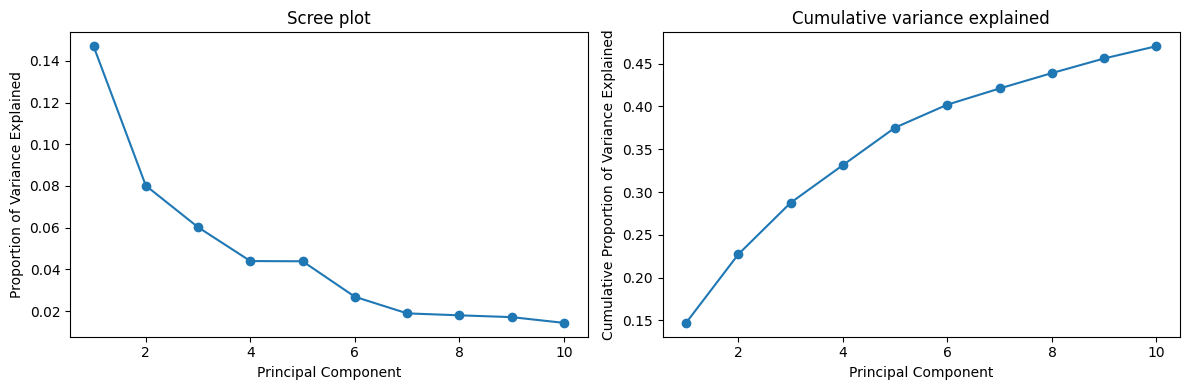


PC1 + PC2 together explain 22.7% of the variance


In [37]:
# --- 3.1a. Scree plot: how much variance does each component explain? ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

components = np.arange(1, len(pca.explained_variance_ratio_) + 1)

axes[0].plot(components, pca.explained_variance_ratio_, marker='o')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].set_title('Scree plot')

axes[1].plot(components, np.cumsum(pca.explained_variance_ratio_), marker='o')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Proportion of Variance Explained')
axes[1].set_title('Cumulative variance explained')

plt.tight_layout()
plt.show()

print()
print(f"PC1 + PC2 together explain {pca.explained_variance_ratio_[:2].sum():.1%} of the variance")

Look at the printed percentage above: that's how much of the total variance in the data our upcoming 2D plot (PC1 vs. PC2) will actually represent. If that number is high, the 2D plot below is a fairly faithful summary of the data. If it's low, there's a lot of structure in the data that a 2D plot simply can't show, and any patterns (or lack of patterns) you see below should be interpreted with that in mind.

Recall from the week 4 material that PC1 and PC2 together explaining more than 50% of the variance is a good benchmark for a trustworthy 2D summary. At less than 25%, this dataset falls well short of that, so this PCA plot should be treated as a partial, likely incomplete picture of the data's real structure. something to keep in mind later in the notebook."

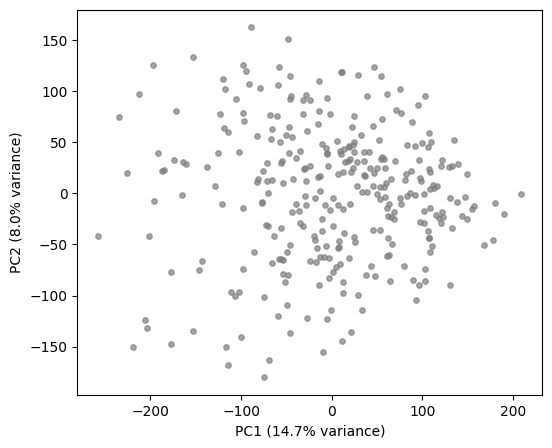

In [38]:
# --- 3.1b. Visualize PC1 vs PC2 ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(embedding_pca[:, 0], embedding_pca[:, 1], c='tab:gray', s=15, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.show()

Take a moment before moving on: does this plot show any visible structure (e.g. separate groups, a gradient, distinct clusters) or does it look like a fairly uniform cloud of points? Keep your impression in mind as we move to t-SNE and UMAP, which take a very different, non-linear approach to the same problem.

#### **3.2) t-distributed Stochastic Neighbor Embedding (t-SNE)**

Unlike PCA, t-SNE is a **non-linear** method: instead of finding straight-line axes, it looks at each sample's closest neighbors in high-dimensional space and tries to keep those neighbors close together in the 2D plot.

This local, neighbor-focused approach makes t-SNE well-suited to non-linear structure that PCA can miss, but it comes with tradeoffs we'll explore below:

- t-SNE has a parameter called **perplexity**, which roughly controls how many neighbors each point considers. Changing it can substantially change the plot, so a t-SNE plot should always be interpreted with its perplexity setting in mind.
- t-SNE starts from a random initialization by default. Running it twice with the same settings can produce visibly different layouts.
- Because t-SNE optimizes for local neighborhoods, *distances between clusters* aren't meaningful. Two groups that look far apart aren't necessarily more different than two that look close together.

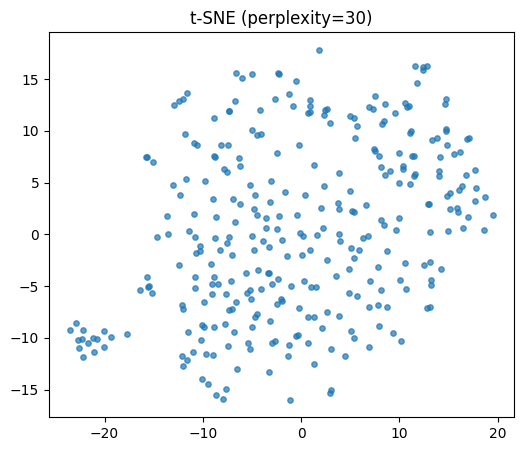

In [39]:
# ============================================
# SECTION 3.2: t-SNE
# ============================================

# Try changing this value (e.g. 5, 15, 30, 50, 100) and re-run.
# What happens to cluster shape and separation at very low vs. very high perplexity?
PERPLEXITY = 30

tsne = TSNE(n_components=2, perplexity=PERPLEXITY, random_state=42, n_jobs=-1)
embedding_tsne = tsne.fit_transform(expression_final)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(embedding_tsne[:, 0], embedding_tsne[:, 1], s=15, alpha=0.7)
ax.set_title(f't-SNE (perplexity={PERPLEXITY})')
plt.show()

**Exploring perplexity**

The three panels below currently show the same perplexity three times. Edit `perplexities_to_try` in the cell below. Pick a low value, a medium value, and a high value and re-run to compare. Watch for how the overall shape of the plot changes: does it look like several small, separate clumps, one or two broader groups, or something in between?

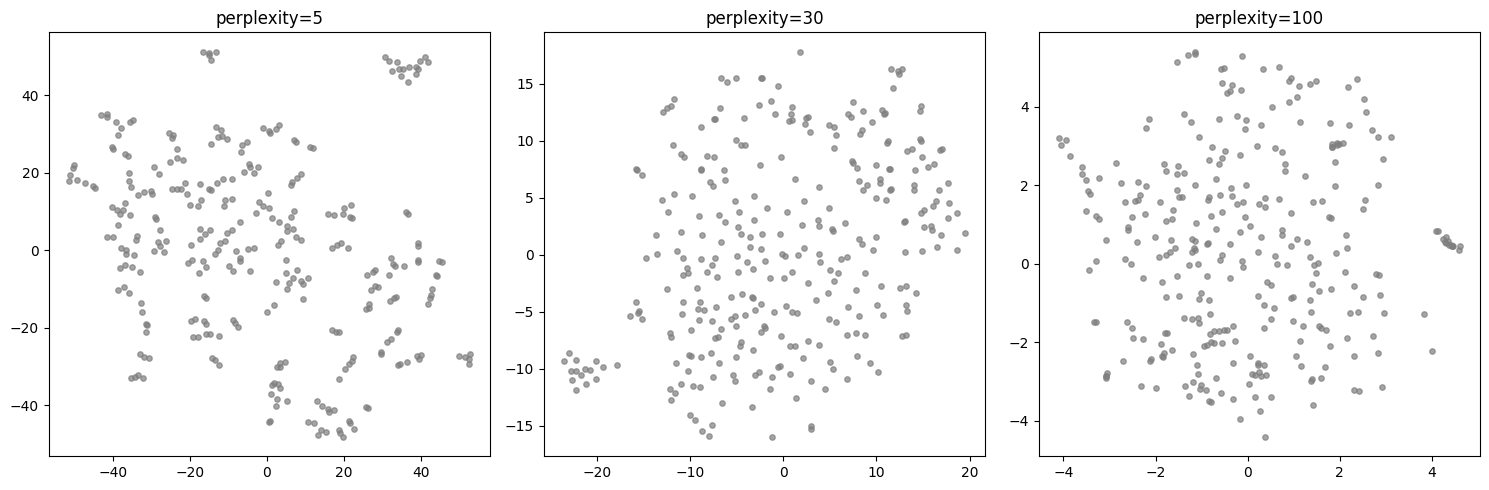

In [40]:
# --- 3.2a. Compare several perplexity values side by side ---

# Edit these three values to compare different perplexities side by side (try values between 2 and 100)
perplexities_to_try = [30, 30, 30]

fig, axes = plt.subplots(1, len(perplexities_to_try), figsize=(5 * len(perplexities_to_try), 5))
for ax, perp in zip(axes, perplexities_to_try):
    tsne_temp = TSNE(n_components=2, perplexity=perp, random_state=42, n_jobs=-1)
    emb_temp = tsne_temp.fit_transform(expression_final)
    ax.scatter(emb_temp[:, 0], emb_temp[:, 1], c='tab:gray', s=15, alpha=0.7)
    ax.set_title(f'perplexity={perp}')

plt.tight_layout()
plt.show()

**Does the random seed matter?**

Now let's hold perplexity fixed and vary only the random seed. Differences between the two plots are a direct illustration of the randomness the second bullet above warned about above.

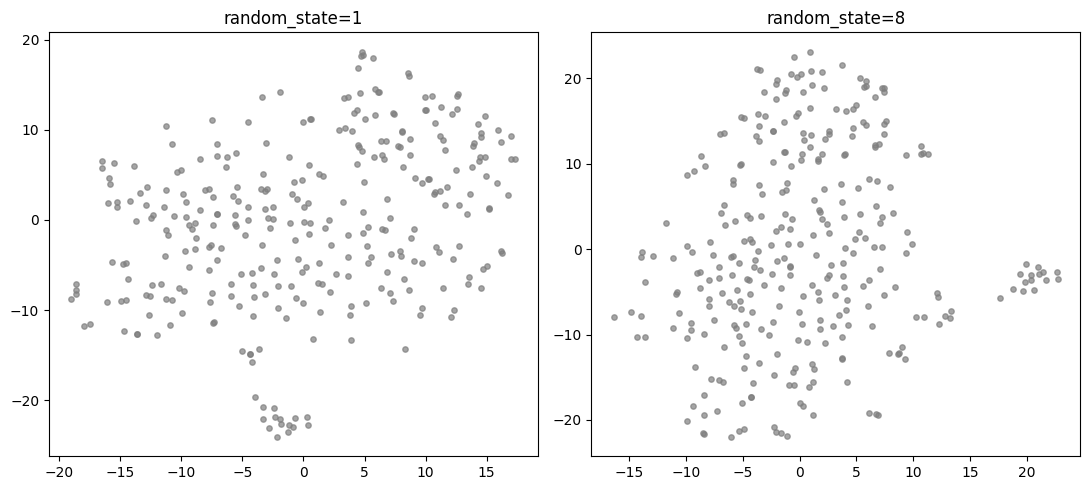

In [41]:
# --- 3.2b. Does the random seed matter? Run t-SNE twice with different seeds ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, seed in zip(axes, [1, 8]):
    tsne_temp = TSNE(n_components=2, perplexity=PERPLEXITY, random_state=seed, n_jobs=-1)
    emb_temp = tsne_temp.fit_transform(expression_final)
    ax.scatter(emb_temp[:, 0], emb_temp[:, 1], c='tab:gray', s=15, alpha=0.7)
    ax.set_title(f'random_state={seed}')

plt.tight_layout()
plt.show()

**Choosing your final t-SNE configuration**

Based on everything you just explored, set your own value below for `FINAL_PERPLEXITY`. This is the configuration we'll carry forward into the clustering work later in this notebook, so pick a value you think best reveals real structure in the data.

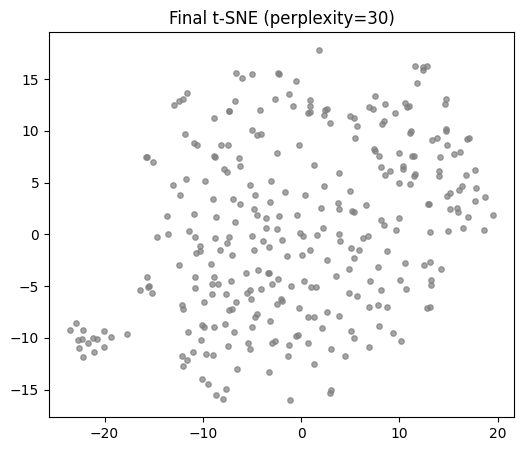

In [42]:
# --- 3.2c. Finalize your t-SNE configuration ---
# Based on what you saw above, set your chosen perplexity here.
# This cell fully regenerates embedding_tsne, so it doesn't matter
# what you ran (or didn't run) earlier in this section.

FINAL_PERPLEXITY = 30

tsne = TSNE(n_components=2, perplexity=FINAL_PERPLEXITY, random_state=42, n_jobs=-1)
embedding_tsne = tsne.fit_transform(expression_final)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(embedding_tsne[:, 0], embedding_tsne[:, 1], c='tab:gray', s=15, alpha=0.7)
ax.set_title(f'Final t-SNE (perplexity={FINAL_PERPLEXITY})')
plt.show()

#### **3.3) Uniform Manifold Approximation and Projection (UMAP)**

Like t-SNE, UMAP is a non-linear method that focuses on preserving local neighborhood structure. With default settings, UMAP's plots often appear to keep the relative arrangement of distinct groups more intact than t-SNE's, though this is more a byproduct of each method's default initialization. The more basic limitation still applies: distances between clusters, and cluster size or density, aren't reliable measures of how different groups actually are. Use UMAP the way you'd use t-SNE: to spot that distinct groups exist, not to judge how far apart or how similar in size and shape they are.

UMAP has two parameters we'll explore below:

- **`n_neighbors`** controls how many neighboring points UMAP considers when estimating the local structure around each sample. Small values focus on very fine, local detail; large values smooth over fine detail in favor of the bigger picture.
- **`min_dist`** controls how tightly points are allowed to pack together in the 2D plot. Low values let points crowd together densely; higher values force more separation, which can make the plot easier to read but doesn't necessarily reflect the data more accurately.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


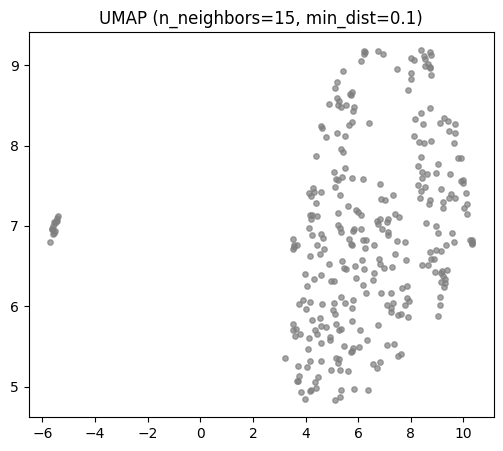

In [43]:
# ============================================
# SECTION 3.3: UMAP
# ============================================

# Try changing these (n_neighbors: 5, 15, 50, 100 / min_dist: 0.0, 0.1, 0.5, 0.9)

N_NEIGHBORS = 15
MIN_DIST = 0.1

reducer = umap.UMAP(n_components=2, n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST,
                     metric='euclidean', random_state=42)
embedding_umap = reducer.fit_transform(expression_final)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(embedding_umap[:, 0], embedding_umap[:, 1], c='tab:gray', s=15, alpha=0.7)
ax.set_title(f'UMAP (n_neighbors={N_NEIGHBORS}, min_dist={MIN_DIST})')
plt.show()

**Exploring `n_neighbors`**

The three panels below currently show the same `n_neighbors` value three times. Edit `neighbors_to_try` in the cell below by picking a small value, a medium value, and a large value and re-run to compare. Notice how the number and size of distinct groupings changes as you adjust this parameter.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


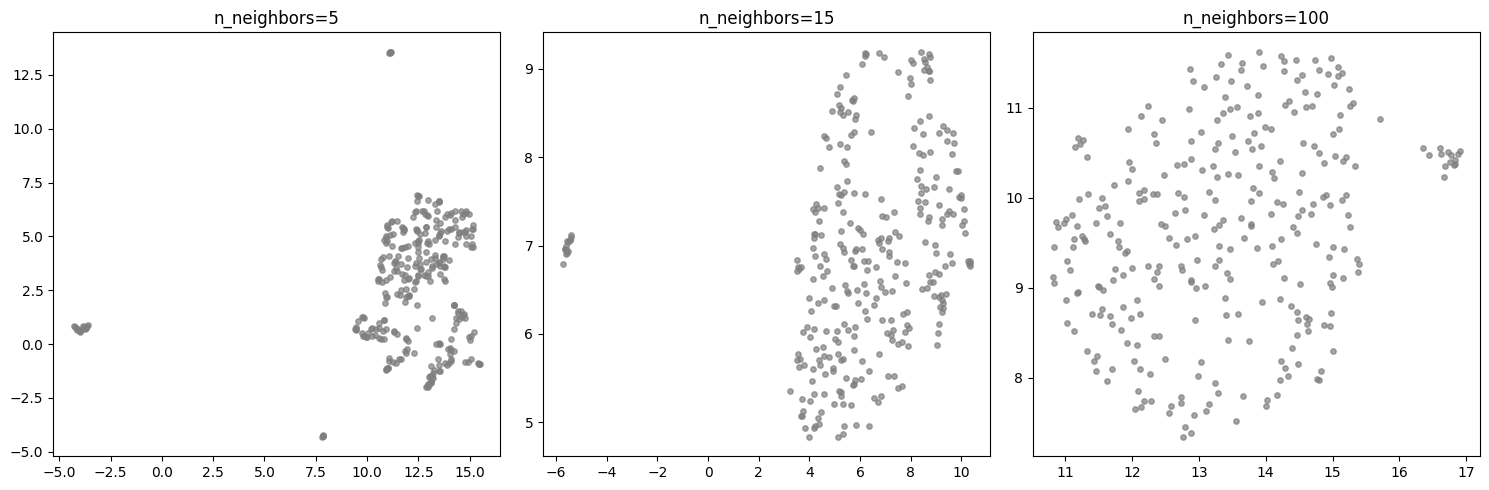

In [44]:
# --- 3.3a. Compare several n_neighbors values side by side ---

# Edit these three values to compare different n_neighbors side by side (try values between 2 and 100)
neighbors_to_try = [15, 15, 15]

fig, axes = plt.subplots(1, len(neighbors_to_try), figsize=(5 * len(neighbors_to_try), 5))
for ax, n in zip(axes, neighbors_to_try):
    reducer_temp = umap.UMAP(n_components=2, n_neighbors=n, min_dist=MIN_DIST,
                              metric='euclidean', random_state=42)
    emb_temp = reducer_temp.fit_transform(expression_final)
    ax.scatter(emb_temp[:, 0], emb_temp[:, 1], c='tab:gray', s=15, alpha=0.7)
    ax.set_title(f'n_neighbors={n}')

plt.tight_layout()
plt.show()

**Exploring `min_dist`**

The three panels below currently show the same `min_dist` value three times. Edit `min_dist_to_try` in the cell below just as you did for `n_neighbors` above and re-run to compare. This parameter mostly affects how the plot looks rather than what structure it's representing: think of it as controlling how "spread out" the same underlying groups appear, rather than changing what those groups are.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


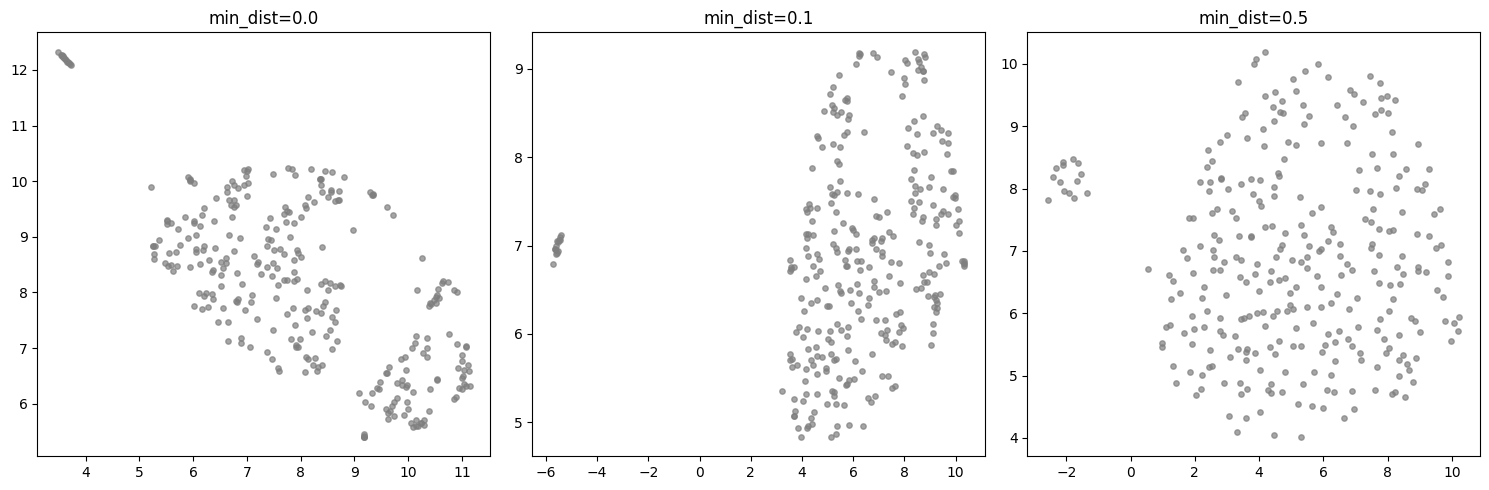

In [45]:
# --- 3.3b. Compare several min_dist values side by side ---

# Edit these three values to compare different min_dist side by side (try values between 0.0 and 0.9)
min_dist_to_try = [0.1, 0.1, 0.1]

fig, axes = plt.subplots(1, len(min_dist_to_try), figsize=(5 * len(min_dist_to_try), 5))
for ax, md in zip(axes, min_dist_to_try):
    reducer_temp = umap.UMAP(n_components=2, n_neighbors=N_NEIGHBORS, min_dist=md,
                              metric='euclidean', random_state=42)
    emb_temp = reducer_temp.fit_transform(expression_final)
    ax.scatter(emb_temp[:, 0], emb_temp[:, 1], c='tab:gray', s=15, alpha=0.7)
    ax.set_title(f'min_dist={md}')

plt.tight_layout()
plt.show()

**Choosing your final UMAP configuration**

Set `FINAL_N_NEIGHBORS` and `FINAL_MIN_DIST` below based on what you found above. As with t-SNE, this is the configuration we'll carry forward into clustering.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


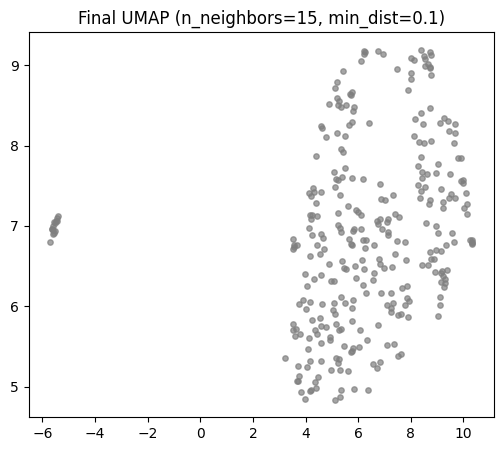

In [46]:
# --- 3.3c. Finalize your UMAP configuration ---
# Based on what you saw above, set your chosen n_neighbors and min_dist here.
# This cell fully regenerates embedding_umap, so it doesn't matter
# what you ran (or didn't run) earlier in this section.

FINAL_N_NEIGHBORS = 15
FINAL_MIN_DIST = 0.1

reducer = umap.UMAP(n_components=2, n_neighbors=FINAL_N_NEIGHBORS, min_dist=FINAL_MIN_DIST,
                     metric='euclidean', random_state=42)
embedding_umap = reducer.fit_transform(expression_final)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(embedding_umap[:, 0], embedding_umap[:, 1], c='tab:gray', s=15, alpha=0.7)
ax.set_title(f'Final UMAP (n_neighbors={FINAL_N_NEIGHBORS}, min_dist={FINAL_MIN_DIST})')
plt.show()

#### **3.4) Comparing all three methods**

Now let's put your finalized PCA, t-SNE, and UMAP embeddings side by side. Look at the shape and structure in each: do all three seem to agree on how many groups exist, and how distinct they are or do they disagree? Keep your impressions in mind; we'll come back to this comparison after we've applied clustering to all three later in this notebook.

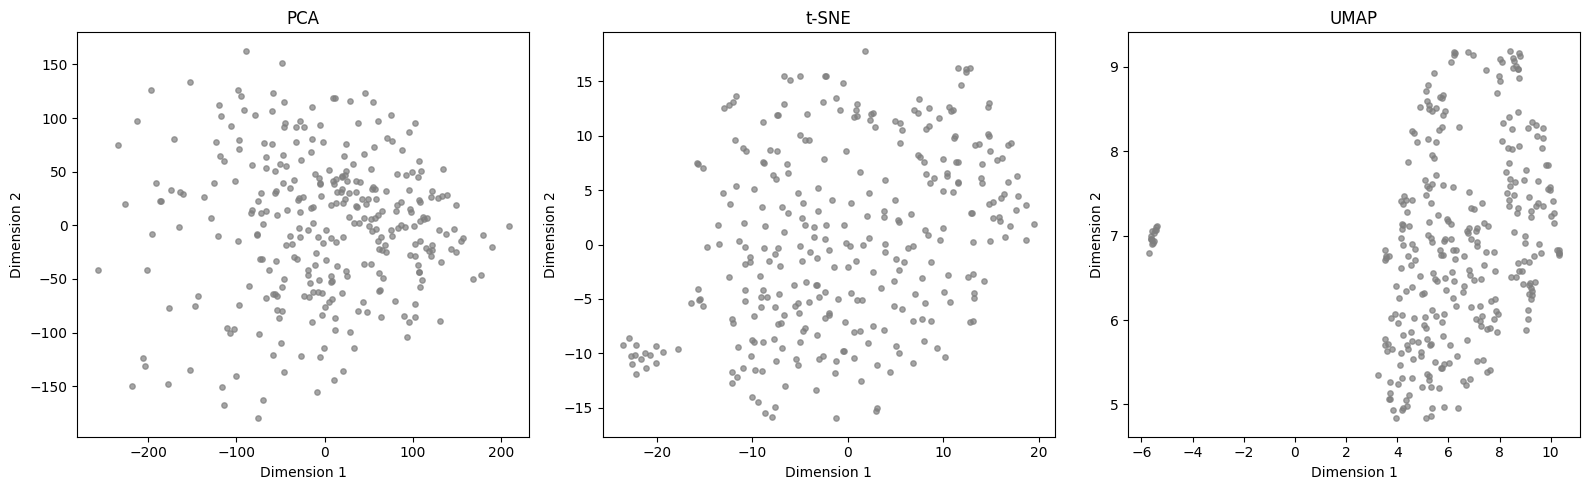

In [47]:
# --- 3.4. Compare your finalized PCA, t-SNE, and UMAP embeddings side by side ---

embeddings = {'PCA': embedding_pca, 't-SNE': embedding_tsne, 'UMAP': embedding_umap}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, emb) in zip(axes, embeddings.items()):
    ax.scatter(emb[:, 0], emb[:, 1], c='tab:gray', s=15, alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')

plt.tight_layout()
plt.show()

### **4) Clustering**

Dimensionality reduction gives us a 2D picture of the data, but it doesn't tell us how many distinct groups exist or which samples belong together. That's the job of **clustering**: a set of methods that assign samples to groups based on how similar they are, without using any labels.

We'll apply clustering to the reduced 2D data from PCA, t-SNE, and UMAP you generated above.

We'll use two clustering methods: **k-means**, which requires you to specify the number of clusters in advance, and **hierarchical clustering**, which builds a nested tree of groupings and lets you decide on a number of clusters afterward. Along the way, we'll check how well-defined each clustering result is, using the elbow method and silhouette score.

#### **4.1) k-means clustering**

K-means clustering works by picking a number of clusters, k, then iteratively assigning each sample to the nearest of k cluster centers, updating those centers, and repeating until assignments stop changing.

The biggest practical question with k-means is: what value of k should you use? We'll look at two tools for answering that below: the elbow plot and the silhouette score. As you'll see, these two tools don't always agree, and reconciling that disagreement is an important part of doing this kind of analysis.

**The elbow plot**

Within-cluster sum of squares (WCSS) measures how tightly grouped the clusters are, and it always decreases as k increases, so we can't just pick the k with the lowest WCSS. Instead, we look for the elbow, which is the point where the curve stops dropping steeply and flattens out. This is the same "point of diminishing returns" logic from the PCA scree plot.

Below, we'll plot WCSS (y-axis) against the number of clusters, k (x-axis), for each of our three embeddings (PCA, t-SNE, and UMAP) and compare.



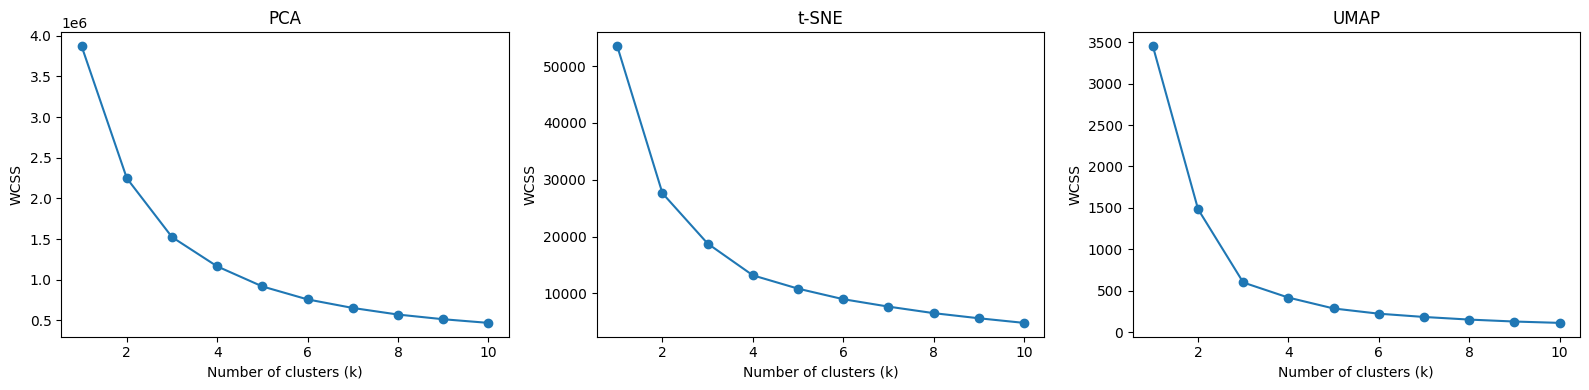

In [48]:
# ============================================
# SECTION 4.1: k-means across PCA, t-SNE, and UMAP
# ============================================

# --- 4.1a. Elbow plot for each embedding ---

embeddings = {'PCA': embedding_pca, 't-SNE': embedding_tsne, 'UMAP': embedding_umap}
k_range = range(1, 11)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, emb) in zip(axes, embeddings.items()):
    wcss = []
    for k in k_range:
        km = KMeans(n_clusters=k, init='random', n_init=10, random_state=0)
        km.fit(emb)
        wcss.append(km.inertia_)
    ax.plot(list(k_range), wcss, marker='o')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('WCSS')
    ax.set_title(name)

plt.tight_layout()
plt.show()

**Does the elbow actually tell the whole story?**

The elbow plots above don't point to one obvious answer for choosing k. The three panels below currently show the same k value three times. Edit `k_to_try` in the cell below and re-run to compare. For each one, look at the resulting clusters plotted on the data: does the split look like it's separating real, distinct groups, or does it look like one group has just been cut into arbitrary pieces?

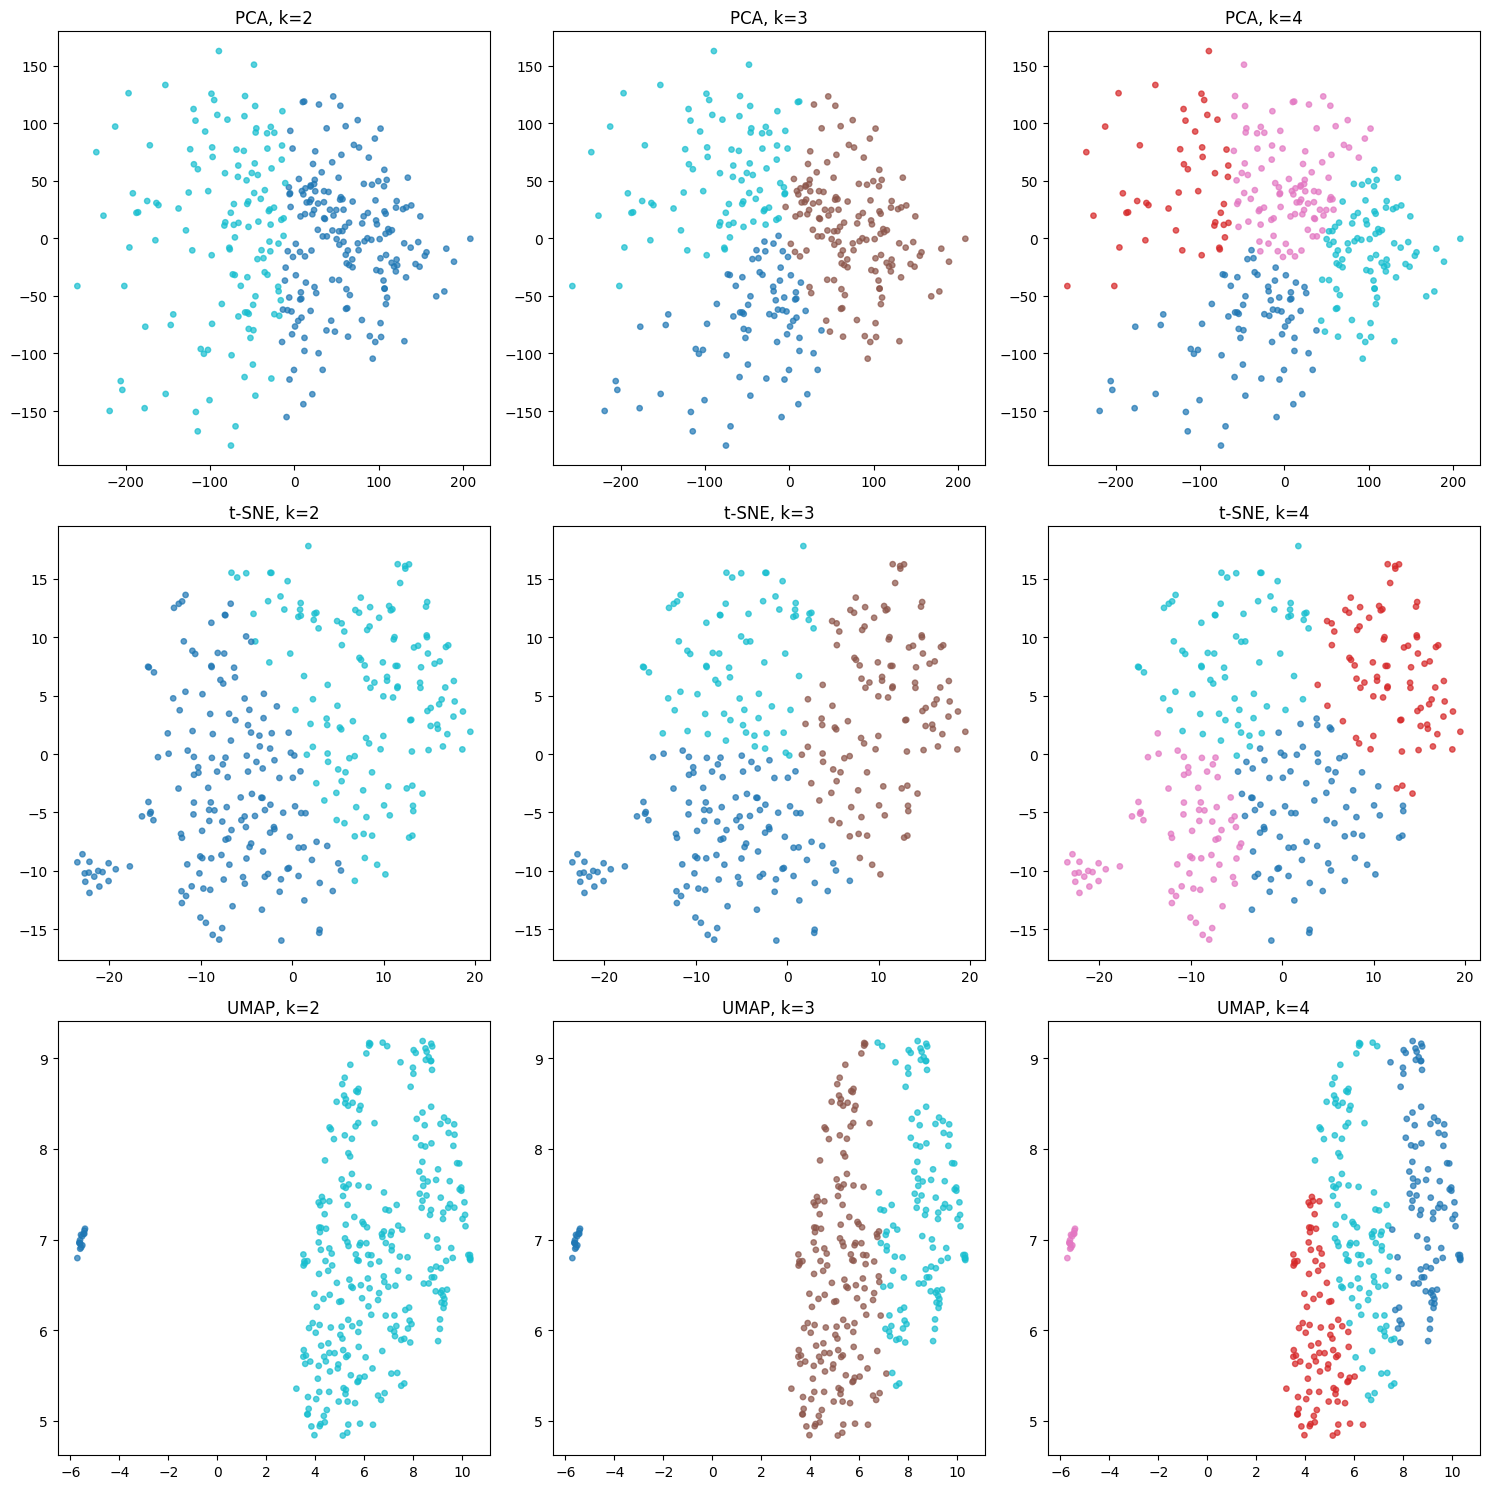

In [49]:
# --- 4.1b. Compare a range of k values across all three embeddings ---

# Rows: PCA, t-SNE, UMAP
# Columns: one per value in k_to_try

# Edit these three values to compare different k values side by side (try values between 2 and 10)
k_to_try = [3, 3, 3]

fig, axes = plt.subplots(3, len(k_to_try), figsize=(5 * len(k_to_try), 15))
for row, (name, emb) in enumerate(embeddings.items()):
    for col, k in enumerate(k_to_try):
        ax = axes[row, col]
        km_temp = KMeans(n_clusters=k, init='random', n_init=10, random_state=0)
        labels_temp = km_temp.fit_predict(emb)
        ax.scatter(emb[:, 0], emb[:, 1], c=labels_temp, cmap='tab10', s=15, alpha=0.7)
        ax.set_title(f'{name}, k={k}')

plt.tight_layout()
plt.show()

**A quantitative check: the silhouette score**

The silhouette score compares how close each sample is to others in its own cluster versus the nearest other cluster. A score near 1 means well-separated, well-defined clusters; near 0 means clusters overlap substantially; negative scores suggest a sample may be in the wrong cluster.

Let's compute the silhouette score across a range of k values, separately for each embedding, and see whether it agrees with your visual impression above. We'll widen this check to k = 2 through 10.

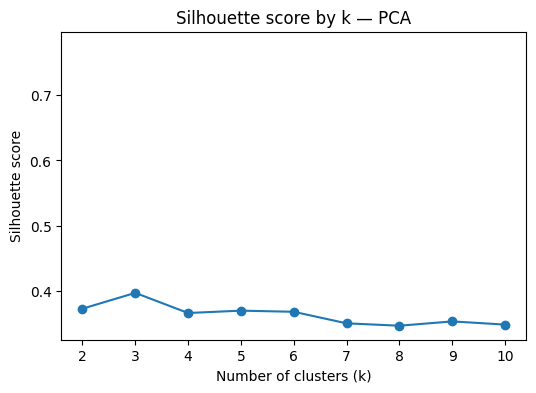

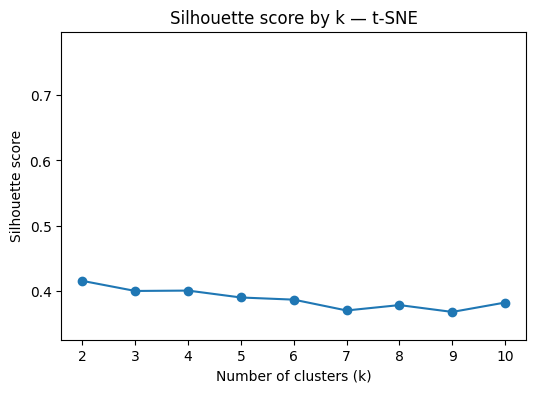

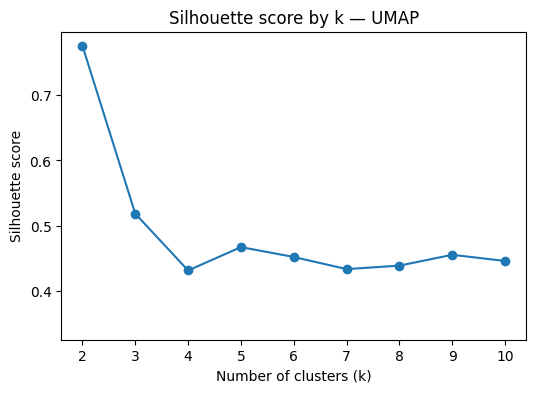

In [50]:
# --- 4.1c. Silhouette score by k, one plot per embedding ---

# First pass: compute silhouette scores for all embeddings so we can share a y-axis scale
k_range_silhouette = range(2, 11)  # silhouette needs at least 2 clusters

all_scores = {}
for name, emb in embeddings.items():
    sil_scores = []
    for k in k_range_silhouette:
        km_temp = KMeans(n_clusters=k, init='random', n_init=10, random_state=0)
        labels_temp = km_temp.fit_predict(emb)
        sil_scores.append(silhouette_score(emb, labels_temp))
    all_scores[name] = sil_scores

# Shared y-axis range across all three plots, with a little padding
y_min = min(min(scores) for scores in all_scores.values())
y_max = max(max(scores) for scores in all_scores.values())
y_pad = 0.05 * (y_max - y_min)

# Second pass: plot each embedding on the same scale
for name, sil_scores in all_scores.items():
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(k_range_silhouette, sil_scores, marker='o')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('Silhouette score')
    ax.set_title(f'Silhouette score by k — {name}')
    ax.set_xticks(k_range_silhouette)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    plt.show()

**Does the starting point matter?**

By default, k-means starts from a random set of centroids, then iteratively moves them until assignments stop changing. So where it starts can affect where it ends up, especially on noisy data. Every `KMeans` call in this notebook has used `n_init=10`, which reruns the process 10 times from different starting placements and keeps the best result (judged by WCSS: the run with the lowest total within-cluster sum of squares wins). That setting has been protecting you from instability the whole time. Below, we turn it off (`n_init=1`) and run k-means on the UMAP embedding at k=2 using a few different values of `random_state` (the number that determines which starting placement k-means uses) to see what an unprotected run can look like.

Note that `random_state` and `n_init` do different jobs: `random_state` controls reproducibility (same code, same result every time you run it), while `n_init` controls how many random starts get tried and compared within a single call.

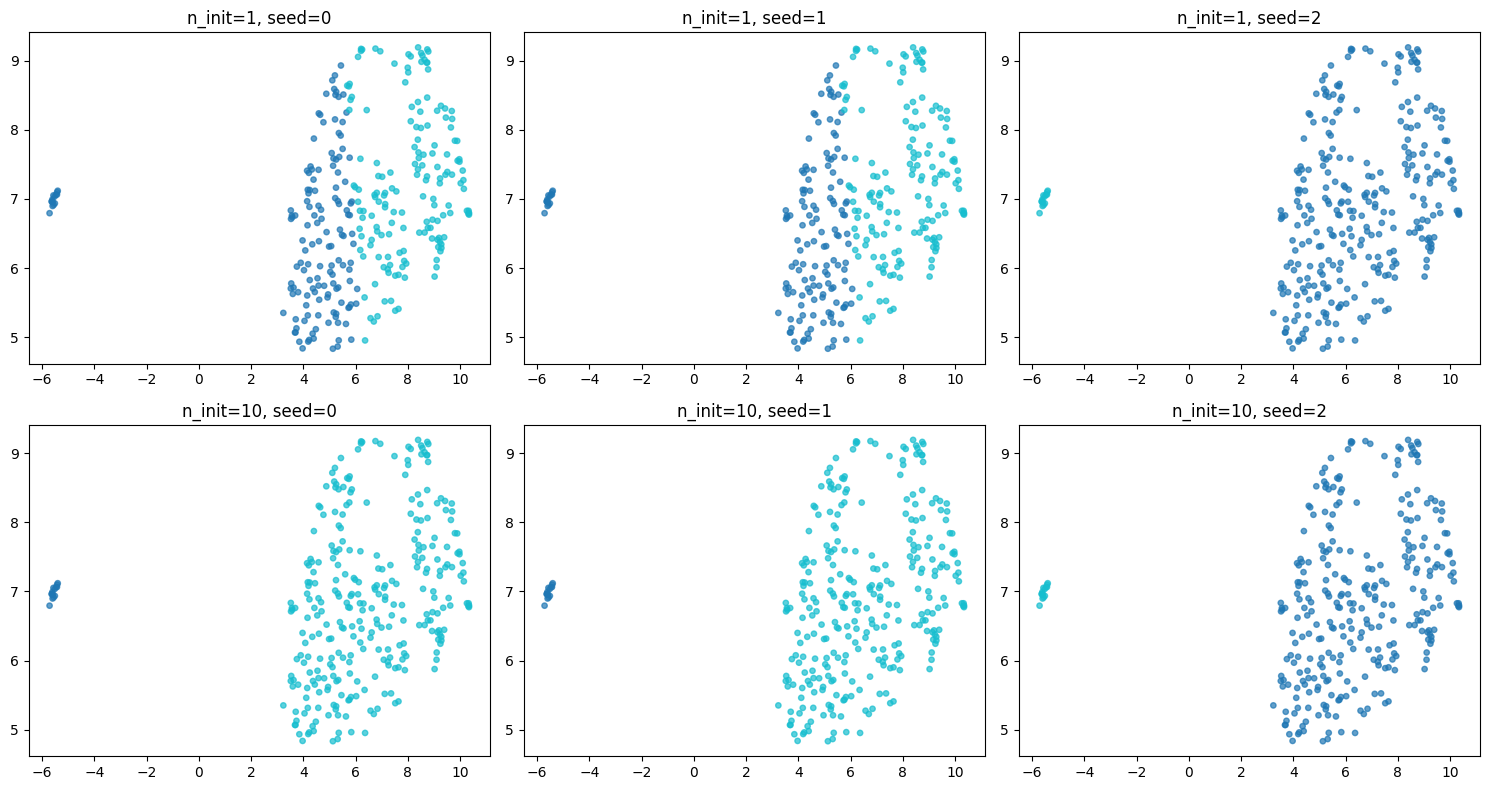

In [51]:
# --- 4.1d. Does the random initialization matter? ---
# Top row: n_init=1 (no safeguard) across a few random seeds
# Bottom row: n_init=10 (the default we've used throughout) with the same seeds
seeds_to_try = [0, 1, 2]

fig, axes = plt.subplots(2, len(seeds_to_try), figsize=(5 * len(seeds_to_try), 8))
for col, seed in enumerate(seeds_to_try):
    km_unsafe = KMeans(n_clusters=2, init='random', n_init=1, random_state=seed)
    labels_unsafe = km_unsafe.fit_predict(embedding_umap)
    axes[0, col].scatter(embedding_umap[:, 0], embedding_umap[:, 1],
                          c=labels_unsafe, cmap='tab10', s=15, alpha=0.7)
    axes[0, col].set_title(f'n_init=1, seed={seed}')

    km_safe = KMeans(n_clusters=2, init='random', n_init=10, random_state=seed)
    labels_safe = km_safe.fit_predict(embedding_umap)
    axes[1, col].scatter(embedding_umap[:, 0], embedding_umap[:, 1],
                          c=labels_safe, cmap='tab10', s=15, alpha=0.7)
    axes[1, col].set_title(f'n_init=10, seed={seed}')

plt.tight_layout()
plt.show()

The k-means results above told a clear story: across k = 2, 3, and 4, UMAP produced the highest silhouette scores by a wide margin, with k = 2 standing out as the strongest fit. PCA and t-SNE, by contrast, produced low, nearly flat scores that barely moved no matter which k we tried. This lines up with what we noted back in Section 3.1: PC1 and PC2 together captured less than 25% of the total variance in the data, so it's not surprising that clustering on that projection doesn't turn up much. Combined with Section 4.1's grid comparison, where PCA's 2D projection barely separated the data at all, that's a strong enough result that we won't repeat the exercise on PCA here. We'll continue with t-SNE and UMAP only

#### **4.2) Hierarchical Clustering**

Hierarchical clustering builds a nested tree instead of choosing k up front, either agglomerative (bottom-up, merging the closest pairs) or divisive (top-down, splitting one big cluster). We'll use agglomerative, since it's what most standard tools, including the one below, implement by default. In the dendrogram, the height at which two branches merge reflects how different those groups are: low merges join similar samples, high merges join very different ones.

Because the whole tree is built at once, you decide how many clusters to keep afterward by choosing a height to cut it at. We'll build dendrograms for t-SNE and UMAP below using Ward's method, which merges clusters in the way that keeps each resulting group as tight as possible.

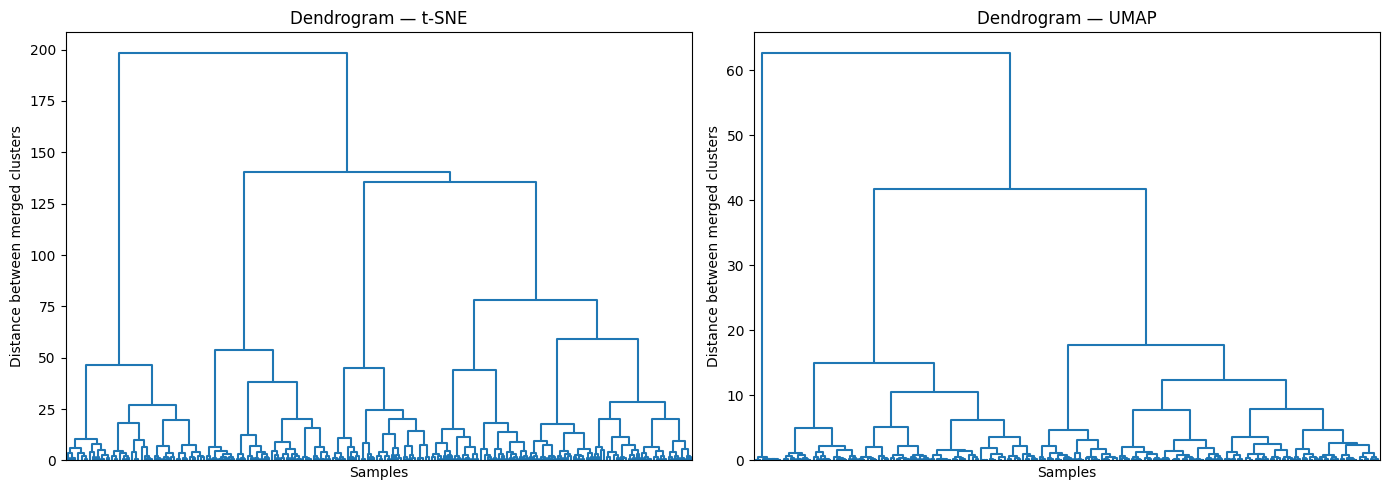

In [52]:
# ============================================
# SECTION 4.2: Hierarchical Clustering
# ============================================
from scipy.cluster.hierarchy import dendrogram, linkage

# Build linkage matrices for t-SNE and UMAP (PCA excluded, per the 4.1 results)
embeddings_hc = {'t-SNE': embedding_tsne, 'UMAP': embedding_umap}
linkage_matrices = {name: linkage(emb, method='ward') for name, emb in embeddings_hc.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, Z) in zip(axes, linkage_matrices.items()):
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0, above_threshold_color='tab:blue')
    ax.set_xlabel('Samples')
    ax.set_ylabel('Distance between merged clusters')
    ax.set_title(f'Dendrogram — {name}')

plt.tight_layout()
plt.show()

**Choosing where to cut**

A dendrogram doesn't give you a cluster count directly, you choose it by deciding where to make a cut in the tree. Look for a large vertical gap between successive merges, and place your cut there. You may notice more than one gap in the dendrogram that looks reasonably large and that it isn't clear which would give the "best" clusters. Thats's part of why we'll check your choice against a quantitative score shortly.

The cut you choose here matters beyond this plot: later in the notebook, we'll use it to compare hierarchical clustering against k-means directly.

One thing to watch for: t-SNE and UMAP produce embeddings on different distance scales, so a cut height that makes sense for one won't automatically make sense for the other. Look at each dendrogram's y-axis separately, then **edit `CUT_HEIGHTS` in the cell below** to set your own cut height for each embedding.

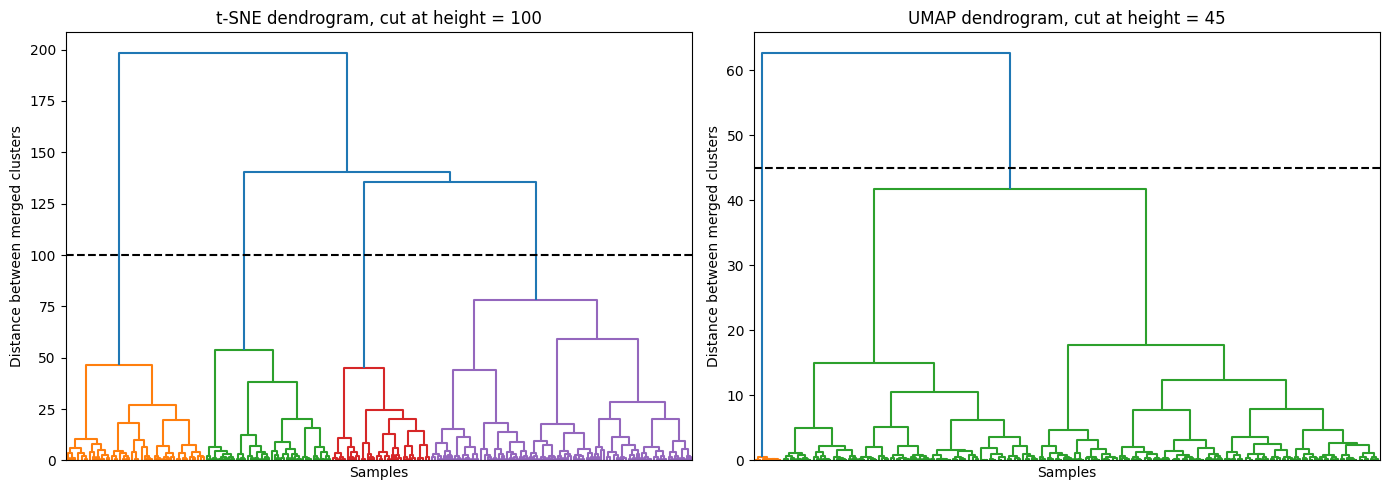

In [53]:
# --- 4.2b. Visualize where a cut would fall on each dendrogram ---
# Look at the y-axis of each dendrogram above and pick a cut height for
# each embedding separately (they're on different scales). Try changing
# these and re-running to see how the coloring (and cluster count) changes.

CUT_HEIGHTS = {'t-SNE': 100, 'UMAP': 45}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, Z) in zip(axes, linkage_matrices.items()):
    cut = CUT_HEIGHTS[name]
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=cut)
    ax.axhline(cut, color='black', linestyle='--')
    ax.set_xlabel('Samples')
    ax.set_ylabel('Distance between merged clusters')
    ax.set_title(f'{name} dendrogram, cut at height = {cut}')

plt.tight_layout()
plt.show()

**Getting the actual cluster assignments**

Now that you've picked a cut height for each embedding, we can extract the cluster label that hierarchical clustering assigned to each sample, based purely on the tree structure and where you cut it. This is not the true diagnosis, we're still working in the unsupervised space and the real labels stay out of sight until the end of the notebook. It's the hierarchical-clustering equivalent of what KMeans.fit_predict() gave us in Section 4.1: a label per sample, just arrived at by cutting a tree rather than by finding k cluster centers.



t-SNE: cut at height 100 produces 4 clusters
UMAP: cut at height 45 produces 2 clusters


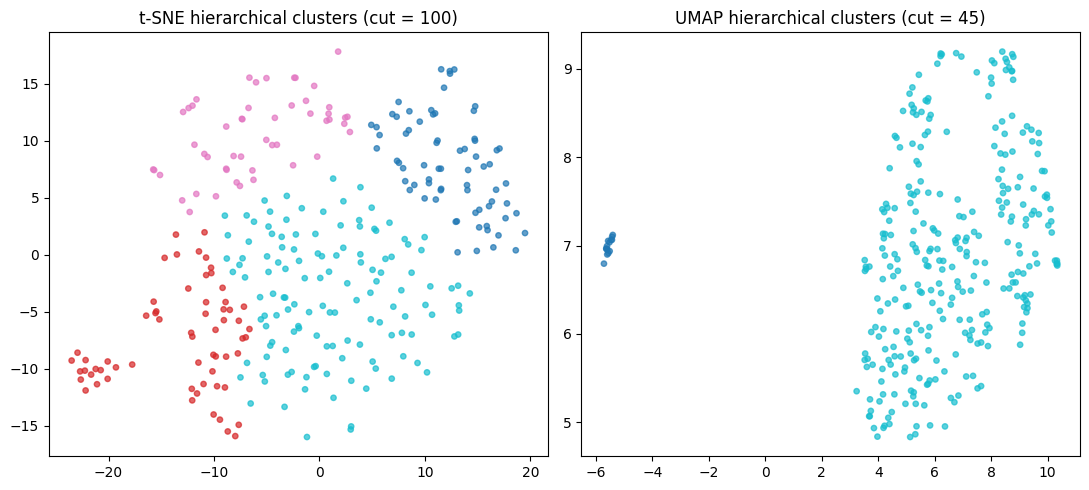

In [54]:
# --- 4.2c. Extract cluster labels from each cut, and plot them on their embedding ---
from scipy.cluster.hierarchy import fcluster

hierarchical_labels = {}

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (name, Z) in zip(axes, linkage_matrices.items()):
    cut = CUT_HEIGHTS[name]
    labels = fcluster(Z, t=cut, criterion='distance')
    hierarchical_labels[name] = labels

    print(f"{name}: cut at height {cut} produces {len(np.unique(labels))} clusters")

    emb = embeddings_hc[name]
    ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap='tab10', s=15, alpha=0.7)
    ax.set_title(f'{name} hierarchical clusters (cut = {cut})')

plt.tight_layout()
plt.show()

**A quantitative check: silhouette score for hierarchical clustering**

The cut heights you chose above were picked by eye, based on where the dendrogram showed a large visual gap, which a reasonable starting point, but worth checking against something more systematic. Just as we did for k-means, we'll compute the silhouette score across a range of cluster counts (2 through 10) using `fcluster`, and check whether the cut you picked actually corresponds to a strong result, or whether a different number of clusters would score better.

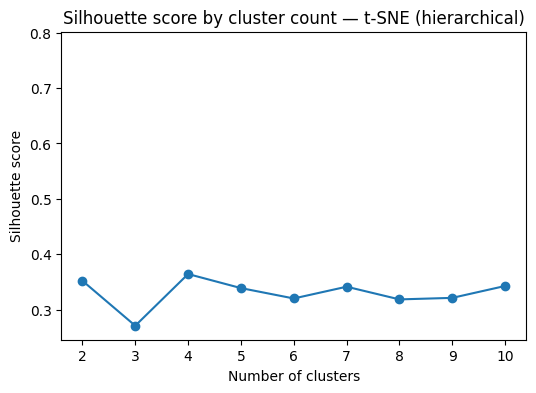

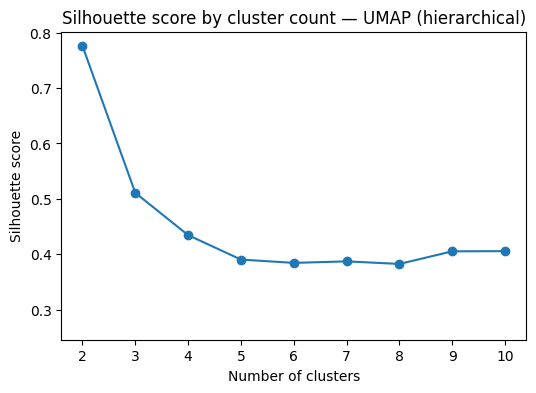

In [55]:
# --- 4.2d. Silhouette score by cluster count for hierarchical clustering, one plot per embedding ---
from scipy.cluster.hierarchy import fcluster

cluster_counts = range(2, 11)

# First pass: compute silhouette scores for both embeddings so we can share a y-axis scale
hc_all_scores = {}
for name, Z in linkage_matrices.items():
    emb = embeddings_hc[name]
    sil_scores = []
    for n in cluster_counts:
        labels_temp = fcluster(Z, t=n, criterion='maxclust')
        sil_scores.append(silhouette_score(emb, labels_temp))
    hc_all_scores[name] = sil_scores

# Shared y-axis range across both plots, with a little padding
y_min = min(min(scores) for scores in hc_all_scores.values())
y_max = max(max(scores) for scores in hc_all_scores.values())
y_pad = 0.05 * (y_max - y_min)

# Second pass: plot each embedding on the same scale
for name, sil_scores in hc_all_scores.items():
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(cluster_counts, sil_scores, marker='o')
    ax.set_xlabel('Number of clusters')
    ax.set_ylabel('Silhouette score')
    ax.set_title(f'Silhouette score by cluster count — {name} (hierarchical)')
    ax.set_xticks(cluster_counts)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    plt.show()

Compare this to the cluster count your cutoff actually produced in 4.2c. If they match, that's a good sign your visual choice of cut height lines up with what the data supports.

#### 4.3) **How much do the two clustering methods agree?**

The plots above let you eyeball whether k-means and hierarchical clustering carve up each embedding the same way, but eyeballing only goes so far. Two cluster maps can look similar or different without a clean way to judge how similar. The adjusted Rand index (ARI) gives us a number for that.

ARI compares two sets of cluster labels for the same samples and asks: how often do the two methods agree on which samples belong together, correcting for the agreement you'd expect by chance alone? A score of 1 means the two methods produced the exact same partition of the data and a score near 0 means the two methods agree no better than if one of them had assigned labels randomly. Negative scores can happen too, and indicate agreement worse than chance.

For this comparison to be valid, both methods need to be producing the same number of clusters, otherwise a low ARI could just mean "these have different cluster counts," not "these disagree on structure." Since your cut height for each embedding may produce a different number of clusters than the default k-means comparisons in Section 4.1, we re-run k-means here with k set to match whatever count hierarchical clustering produced at your chosen cut, so it's an apples-to-apples comparison.

If you want to compare a different number of clusters, go back to 4.2b and change the cut height for that embedding. The k-means k in the cell below will adjust automatically to match, since it's set from the hierarchical cluster count rather than a fixed value.

To be clear about what this number tells us: a high ARI here means k-means and hierarchical clustering agree with each other, which is a sign the clustering result is robust to which algorithm you choose but it says nothing about whether either method's clusters match the true diagnosis. That's still coming up.

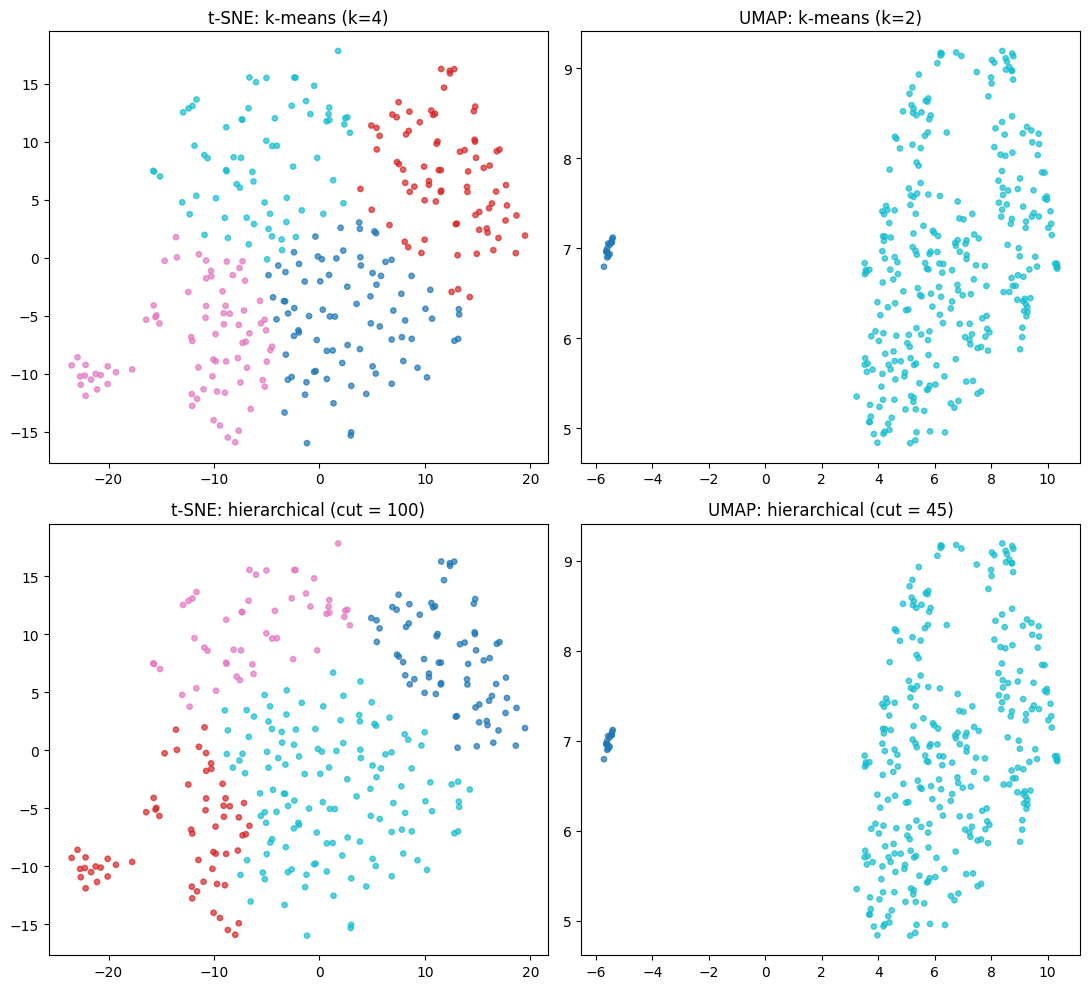

Embedding    Clusters      ARI
t-SNE               4    0.614
UMAP                2    1.000


In [56]:
# --- 4.3. Comparing k-means and hierarchical clustering ---
from sklearn.metrics import adjusted_rand_score

comparison_labels = {}
n_clusters_by_embedding = {}

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for col, name in enumerate(embeddings_hc):
    emb = embeddings_hc[name]
    n_clusters_hc = len(np.unique(hierarchical_labels[name]))
    n_clusters_by_embedding[name] = n_clusters_hc

    # Match k-means to the same number of clusters hierarchical clustering
    # produced at your chosen cut, so the comparison is apples-to-apples.
    km_temp = KMeans(n_clusters=n_clusters_hc, init='random', n_init=10, random_state=0)
    kmeans_labels = km_temp.fit_predict(emb)
    comparison_labels[name] = {'kmeans': kmeans_labels, 'hierarchical': hierarchical_labels[name]}

    axes[0, col].scatter(emb[:, 0], emb[:, 1], c=kmeans_labels, cmap='tab10', s=15, alpha=0.7)
    axes[0, col].set_title(f'{name}: k-means (k={n_clusters_hc})')

    axes[1, col].scatter(emb[:, 0], emb[:, 1], c=hierarchical_labels[name], cmap='tab10', s=15, alpha=0.7)
    axes[1, col].set_title(f'{name}: hierarchical (cut = {CUT_HEIGHTS[name]})')

plt.tight_layout()
plt.show()

print(f"{'Embedding':<10} {'Clusters':>10} {'ARI':>8}")
for name in embeddings_hc:
    ari = adjusted_rand_score(comparison_labels[name]['kmeans'], comparison_labels[name]['hierarchical'])
    print(f"{name:<10} {n_clusters_by_embedding[name]:>10} {ari:>8.3f}")

Before you continue: in Section 3.3, using the values already filled in before you made any edits (`n_neighbors`=15, `min_dist`=0.1), a small cluster of roughly 15–20 points split off from the rest of the data. Take a guess: what do you think this cluster represents, and what's your reasoning? Keep your answer in mind as we reveal the true labels below.

### **5) Revealing the True Labels**

Throughout this notebook, you've been working the way you would if you didn't already know which samples were healthy and which had SLE: exploring structure, choosing parameters, and evaluating clusters using only the data itself. But we do have that information, it's been sitting in `metadata['diagnosis']` since Section 1, deliberately unused until now.

Below, we color the t-SNE and UMAP embeddings by true diagnosis instead of by cluster assignment. Compare this to the cluster plots from Sections 4.1 and 4.2: does the structure you found on your own line up with the real groups, or not?

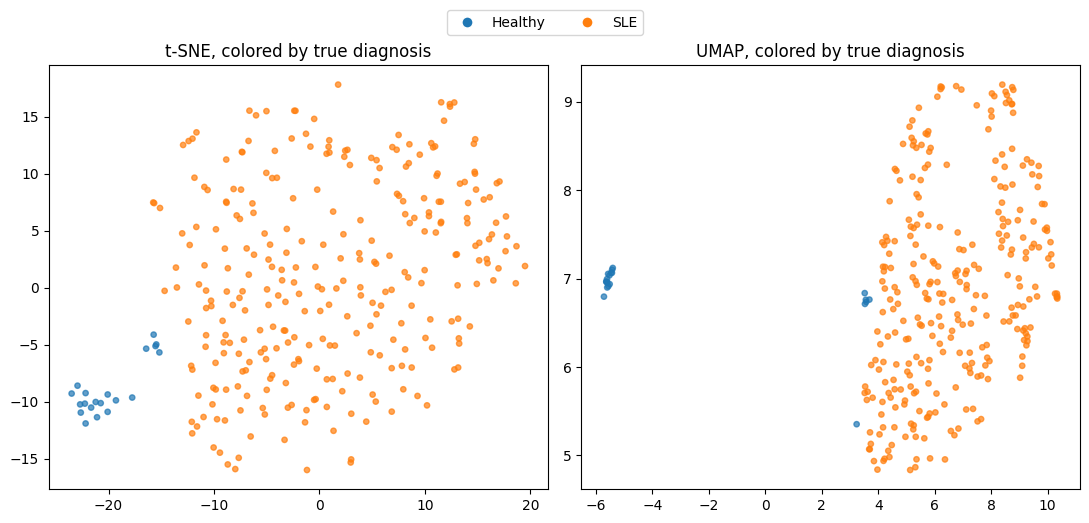

In [57]:
# --- 5a. Visualize t-SNE and UMAP colored by true diagnosis ---
diagnosis_colors = metadata['diagnosis'].map({'Healthy': 'tab:blue', 'SLE': 'tab:orange'})

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (name, emb) in zip(axes, embeddings_hc.items()):
    ax.scatter(emb[:, 0], emb[:, 1], c=diagnosis_colors, s=15, alpha=0.7)
    ax.set_title(f'{name}, colored by true diagnosis')

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=l)
           for l, c in [('Healthy', 'tab:blue'), ('SLE', 'tab:orange')]]
fig.legend(handles=handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()

**A quantitative check: does clustering recover the true diagnosis?**

The plots above give a visual impression, but we already have a tool for measuring agreement precisely: the adjusted Rand index, which we used in Section 4.2 to compare k-means against hierarchical clustering. We can use it exactly the same way here, just swapping one of the two label sets for the true diagnosis instead of a second clustering method. The interpretation is the same as before: 1 means perfect agreement, 0 means agreement no better than chance, and negative values mean agreement worse than chance.

In [58]:
# --- 5b. ARI: clustering results vs. true diagnosis ---
true_labels = metadata['diagnosis'].map({'Healthy': 0, 'SLE': 1}).values

print(f"{'Embedding':<10} {'Method':<14} {'ARI vs. true diagnosis':>24}")
for name in embeddings_hc:
    for method in ['kmeans', 'hierarchical']:
        labels = comparison_labels[name][method]
        ari = adjusted_rand_score(true_labels, labels)
        print(f"{name:<10} {method:<14} {ari:>24.3f}")

Embedding  Method           ARI vs. true diagnosis
t-SNE      kmeans                            0.017
t-SNE      hierarchical                      0.052
UMAP       kmeans                            0.796
UMAP       hierarchical                      0.796


**What does this tell us?**

The agreement between our clustering and the true diagnosis depends heavily on how many clusters we asked for. At k = 2, UMAP's clustering, by either k-means or hierarchical clustering, achieves an ARI of nearly 0.8 against true diagnosis, a strong result. t-SNE's clustering, by contrast, doesn't fare as well against the true labels, consistent with what we saw throughout Sections 4.1 and 4.2.

Back in Section 4.1, before the true labels were ever shown, the silhouette score for UMAP was highest at k=2, clearly higher than at k=3 or k=4. That means the strongest cluster count was discoverable directly from the data, using only unsupervised information. It's a useful reminder of why we pushed you to check the silhouette score rather than stopping at a visually chosen elbow or a dendrogram cut picked by eye: those quantitative checks can change the number of clusters you settle on, and here that number turns out to really matter.

This also calls back to something we flagged back in Section 1: the dataset's class imbalance (292 SLE vs. 20 healthy) meant the healthy group was always going to be a small, easily-overlooked cluster relative to the rest of the data, exactly the kind of cluster you noticed splitting off throughout Section 3.3

One limitation worth noting: the dendrogram cut you chose in Section 4.2b was chosen by eye, looking for a large visual gap, without a quantitative check at the time. If your cut happened to land on 3 clusters instead of 2, this is a good moment to go back, compare the cut heights that produce 2 versus 3 clusters, and see which one the silhouette score actually favors.

**Open questions**

Even with a strong overall result, the UMAP embedding doesn't perfectly separate healthy samples from SLE samples. Some healthy samples fall inside or near the larger SLE-associated cluster. There are a few possible explanations, and this dataset alone doesn't let us distinguish between them:

1. A hidden technical or batch covariate could be influencing the embedding. Yang et al. reported exactly this kind of effect in a different dataset (GEO: GSE71220), where clustering structure turned out to be driven by gender rather than the biological variable of interest.
2. Some of the overlap could reflect real biological ambiguity, for example healthy individuals with subclinical immune activity, or SLE patients sampled during a period of low disease activity.
3. Cell-type composition differences between samples, unrelated to diagnosis, could also be contributing to the expression differences UMAP is picking up on.

We don't have enough metadata in this exercise to distinguish between these explanations. It's also worth remembering that our 312 samples came from only 65 SLE patients sampled at multiple visits, plus 20 healthy controls. Multiple samples from the same patient are not independent of each other, so this analysis likely overstates how much independent evidence we actually have. A more rigorous analysis would need to account for this repeated-measures structure directly, rather than treating every sample as if it came from a different person.